In [1]:
import os
os.chdir("..")

In [221]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from esda.moran import Moran
from libpysal.weights import Queen

import contextily as ctx

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [277]:
import warnings
warnings.filterwarnings("ignore")

In [271]:
df_org = pd.read_csv("data/processed/final_dataset_de.csv")
df = df_org.copy()
temp = pd.read_excel("data/temperature_2006_daily.xlsx")

In [261]:
# Gross Domestic Product 2006 per Capita in € | NUTS2

gdp = pd.read_csv("data/gross_domestic_product_per_capita_nuts2.csv")
gdp['State'] = [i.title() for i in gdp['State']]

In [262]:
# Disposable income and distribution accounts of households 2006 per Capita | NUTS2

inc = pd.read_csv("data/disposable_income_per_capita.csv")

In [263]:
# https://link.springer.com/article/10.1007/s00508-021-01941-9

bmi = pd.read_csv("data/weight_data_nuts2.csv")

In [264]:
df['datetime'] = pd.to_datetime(df['zeit'])

df['date'] = df['datetime'].dt.date
df['time'] = df['datetime'].dt.time

In [265]:
temp['time'] = pd.to_datetime(temp['time'])
temp['date'] = temp['time'].dt.date
temp['time'] = temp['time'].dt.time

In [266]:
df = pd.merge(df, temp, on='date')

In [ ]:
bp_state = (
    df
    .groupby("bundesland")[["messwert_bp_sys", "messwert_bp_dia"]]
    .mean()
    .reset_index()
)

bp_state.columns = [
    "bundesland",
    "avg_sys_bp",
    "avg_dia_bp"
]

In [ ]:
gdf_states = gpd.read_file("geospace/gadm41_AUT_1.shp")
gdf_states['bundesland'] = gdf_states['NAME_1']

### GDP vs BP

In [228]:
merged_df = bp_state.merge(gdp, left_on="bundesland", right_on='State')

In [229]:
corr_sys, p_sys = pearsonr(
    merged_df["Euros"],
    merged_df["avg_sys_bp"]
)

corr_dia, p_dia = pearsonr(
    merged_df["Euros"],
    merged_df["avg_dia_bp"]
)

print("Systolic BP Correlation")
print("Correlation:", corr_sys)
print("P-value:", p_sys)

print("\nDiastolic BP Correlation")
print("Correlation:", corr_dia)
print("P-value:", p_dia)

Systolic BP Correlation
Correlation: -0.4327143258716324
P-value: 0.24470279906574072

Diastolic BP Correlation
Correlation: -0.325404094569614
P-value: 0.3928353610124222


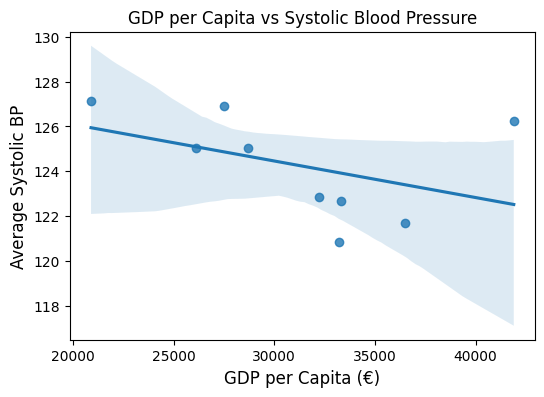

In [230]:
plt.figure(figsize=(6, 4))

sns.regplot(
    data=merged_df,
    x="Euros",
    y="avg_sys_bp"
)

plt.title("GDP per Capita vs Systolic Blood Pressure")
plt.xlabel("GDP per Capita (€)", fontsize=12)
plt.ylabel("Average Systolic BP", fontsize=12)

plt.show()

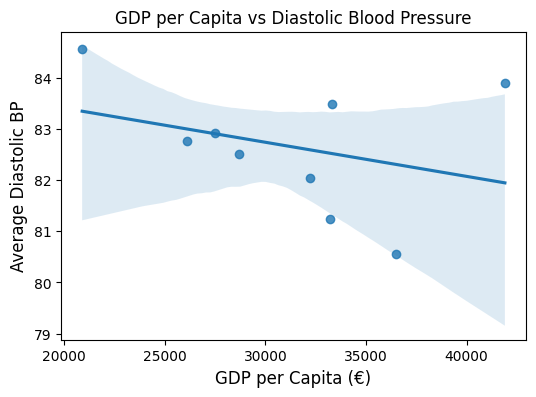

In [231]:
plt.figure(figsize=(6, 4))

sns.regplot(
    data=merged_df,
    x="Euros",
    y="avg_dia_bp"
)

plt.title("GDP per Capita vs Diastolic Blood Pressure")
plt.xlabel("GDP per Capita (€)", fontsize=12)
plt.ylabel("Average Diastolic BP", fontsize=12)

plt.show()

In [232]:
map_gdf = gdf_states.merge(
    merged_df,
    left_on="bundesland",
    right_on="State"
)

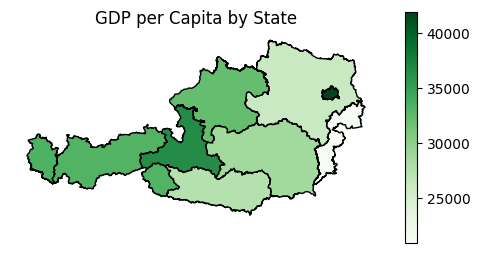

In [235]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

map_gdf.plot(
    column="Euros",
    cmap="Greens",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("GDP per Capita by State")
ax.axis("off")

plt.show()

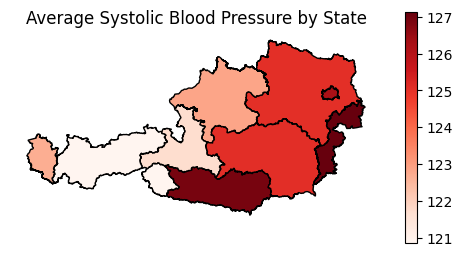

In [238]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

map_gdf.plot(
    column="avg_sys_bp",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("Average Systolic Blood Pressure by State")
ax.axis("off")

plt.show()

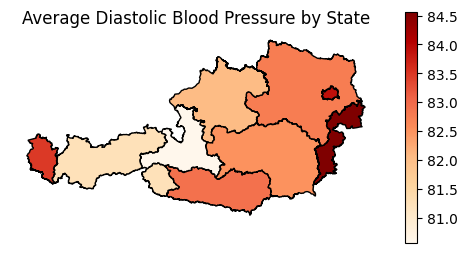

In [239]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

map_gdf.plot(
    column="avg_dia_bp",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("Average Diastolic Blood Pressure by State")
ax.axis("off")

plt.show()

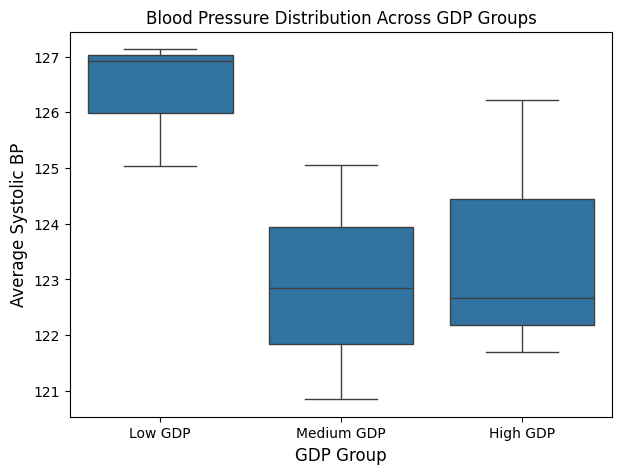

In [128]:
merged_df["gdp_group"] = pd.qcut(
    merged_df["Euros"],
    q=3,
    labels=["Low GDP", "Medium GDP", "High GDP"]
)

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=merged_df,
    x="gdp_group",
    y="avg_sys_bp"
)

plt.title("Blood Pressure Distribution Across GDP Groups")
plt.xlabel("GDP Group", fontsize=12)
plt.ylabel("Average Systolic BP", fontsize=12)

plt.show()

### Income vs BP

In [248]:
merged_df = bp_state.merge(inc, left_on="bundesland", right_on='State')

In [249]:
# Merge with shapefile
map_gdf = gdf_states.merge(
    merged_df,
    left_on="bundesland",
    right_on="State"
)

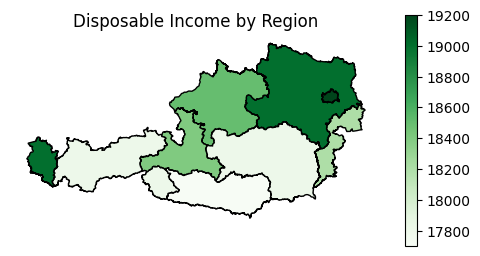

In [251]:
# Plot disposable income
fig, ax = plt.subplots(figsize=(6, 3))

map_gdf.plot(
    column="Euros",
    cmap="Greens",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("Disposable Income by Region")
ax.axis("off")

plt.show()

### Overweight vs BP

In [244]:
merged_df = bp_state.merge(bmi, left_on="bundesland", right_on='State')

In [245]:
# Merge
map_gdf = gdf_states.merge(
    merged_df,
    left_on="bundesland",
    right_on="State"
)

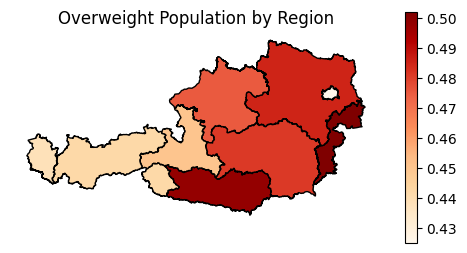

In [246]:
# Plot overweight prevalence
fig, ax = plt.subplots(figsize=(6, 3))

map_gdf.plot(
    column="Overweight (BMI >= 25)",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("Overweight Population by Region")
ax.axis("off")

plt.show()

Correlation: -0.9006469743235778
P-value: 0.0009224811341753624


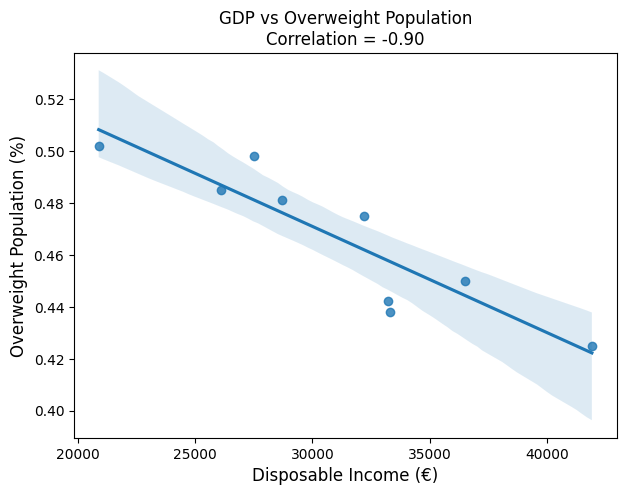

In [256]:
# Merge BMI with GDP
bmi_gdp = bmi.merge(
    gdp,
    on="State",
)

# Correlation
corr, pval = pearsonr(
    analysis_df["Euros"],
    analysis_df["Overweight (BMI >= 25)"]
)

print("Correlation:", corr)
print("P-value:", pval)

# Plot
plt.figure(figsize=(7, 5))

sns.regplot(
    data=bmi_gdp,
    x="Euros",
    y="Overweight (BMI >= 25)"
)

plt.title(
    f"GDP vs Overweight Population\nCorrelation = {corr:.2f}"
)

plt.xlabel("Disposable Income (€)", fontsize=12)
plt.ylabel("Overweight Population (%)", fontsize=12)

plt.show()

Correlation: 0.22164387628531693
P-value: 0.566549420918935


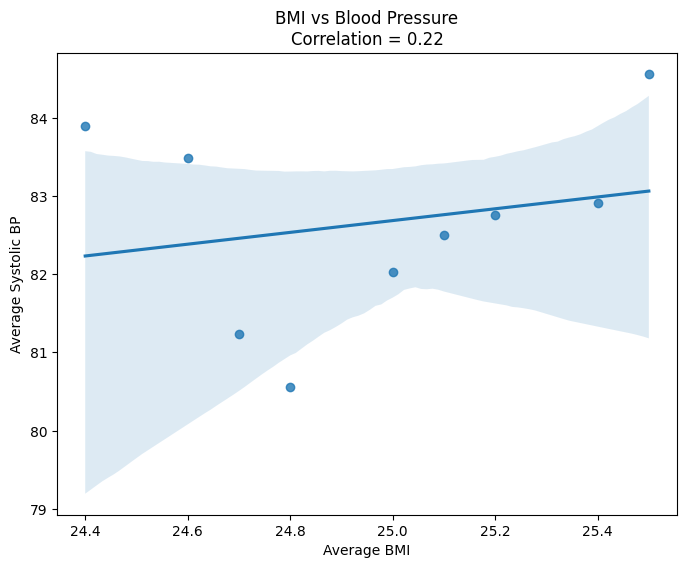

In [166]:
# Correlation
corr_bp, pval_bp = pearsonr(
    merged_df["Average BMI (kg/m²)"],
    merged_df["avg_dia_bp"]
)

print("Correlation:", corr_bp)
print("P-value:", pval_bp)

# Plot
plt.figure(figsize=(8, 6))

sns.regplot(
    data=merged_df,
    x="Average BMI (kg/m²)",
    y="avg_dia_bp"
)

plt.title(
    f"BMI vs Blood Pressure\nCorrelation = {corr_bp:.2f}"
)

plt.xlabel("Average BMI")
plt.ylabel("Average Systolic BP")

plt.show()

### NEAP

In [279]:
df_neap = df_org[df_org["postleitzahl"].map(df_org["postleitzahl"].value_counts()) > 10]

In [280]:
# neighborhood definition
group_col = "postleitzahl"

# target variable
target = "messwert_bp_sys"

df_neap["neighborhood_mean_bp"] = df_neap.groupby(group_col)[target].transform("mean")

In [281]:
df_neap["bp_minus_neighborhood"] = df_neap[target] - df_neap["neighborhood_mean_bp"]

In [282]:
df_neap["raucher"] = df_neap["raucher"].map({True: 1, False: 0})
df_neap["cholesterin_bekannt"] = df_neap["cholesterin_bekannt"].map({True: 1, False: 0})

In [284]:
X = df_neap[["geburtsjahr", "raucher", "cholesterin_bekannt"]]
X = sm.add_constant(X)
y = df_neap["messwert_bp_sys"]

model1 = sm.OLS(y, X).fit()

model2.params

In [286]:
X = df_neap[["geburtsjahr", "raucher", "cholesterin_bekannt", "neighborhood_mean_bp"]]
X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()

model2.params

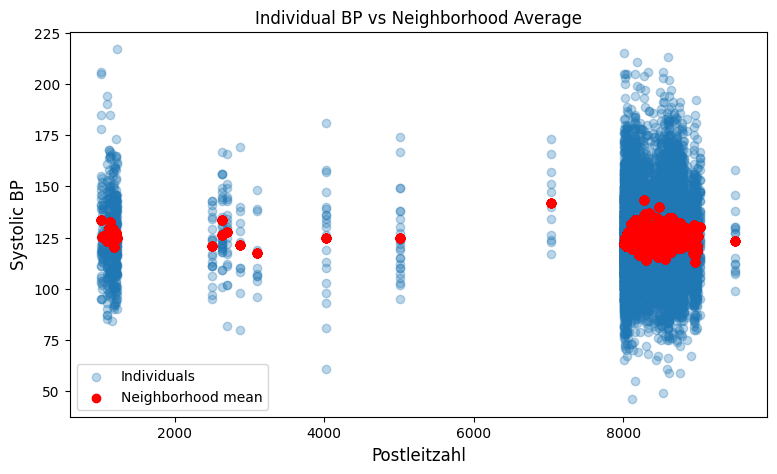

In [311]:
plt.figure(figsize=(9,5))

plt.scatter(df_neap["postleitzahl"], df_neap["messwert_bp_sys"], alpha=0.3, label="Individuals")
plt.scatter(df_neap["postleitzahl"], df_neap["neighborhood_mean_bp"], color="red", label="Neighborhood mean")

plt.xlabel("Postleitzahl", fontsize=12)
plt.ylabel("Systolic BP", fontsize=12)
plt.legend()
plt.title("Individual BP vs Neighborhood Average")
plt.show()

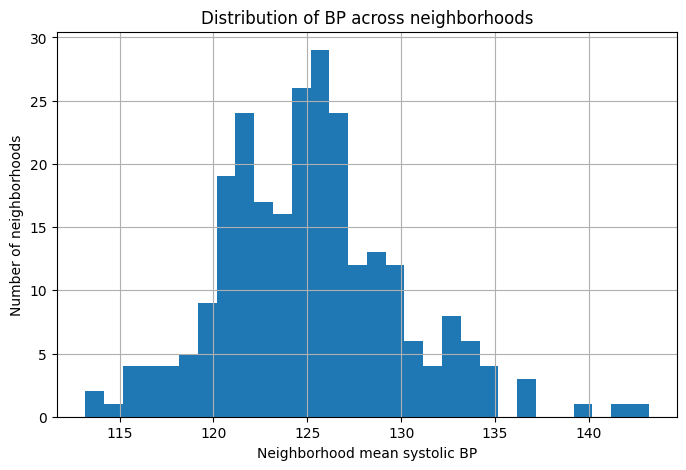

In [292]:
plt.figure(figsize=(8,5))

df_neap.groupby("postleitzahl")["messwert_bp_sys"].mean().hist(bins=30)

plt.xlabel("Neighborhood mean systolic BP")
plt.ylabel("Number of neighborhoods")
plt.title("Distribution of BP across neighborhoods")
plt.show()

In [307]:
# Drop missing values in key columns
data = df_neap.dropna(subset=["postleitzahl", "messwert_bp_sys"])

In [308]:
model = smf.mixedlm(
    "messwert_bp_sys ~ 1",
    data,
    groups=data["postleitzahl"]
).fit()

var_between = model.cov_re.iloc[0, 0]
var_within = model.scale

icc = var_between / (var_between + var_within)

icc

0.01773177582844219